In [ ]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


Don't know how to reset  #, please run `%reset?` for details
Don't know how to reset  to, please run `%reset?` for details
Don't know how to reset  clear, please run `%reset?` for details
Don't know how to reset  saved, please run `%reset?` for details
Don't know how to reset  variables, please run `%reset?` for details
Don't know how to reset  for, please run `%reset?` for details
Don't know how to reset  new, please run `%reset?` for details
Don't know how to reset  session, please run `%reset?` for details


In [ ]:
import pickle
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

final_df= pd.read_pickle('final_df3.pkl')
print(final_df)

     Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId  \
0    1951 -4.362798    6.185266    9.747061     10.721021     2636.0   
1    1952 -2.419369    8.807426    9.220020     12.433246     2636.0   
2    1953 -5.094279    7.743274   10.786901     11.524487     2636.0   
3    1954 -3.825318    5.963656   10.494399     12.956203     2636.0   
4    1955 -4.074505    7.468448    9.956315      9.585814     2636.0   
..    ...       ...         ...         ...           ...        ...   
545  2022 -2.855950    9.078746   11.289492     13.741344     2768.0   
546  2022 -2.855950    9.078746   11.289492     13.741344       54.0   
547  2022 -2.855950    9.078746   11.289492     13.741344     2297.0   
548  2022 -2.855950    9.078746   11.289492     13.741344     2968.0   
549  2022 -2.855950    9.078746   11.289492     13.741344     2636.0   

              Glacier    Bs    Bw    Ba  ...    SSRD_DJF  SSRD_MJJAS  \
0           Storbreen -1.67  1.13 -0.54  ...  2980521.00  75456

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(final_df)

# For corelating and comparing NAO (Hurell) and PC1 (DJF) from my EOF analysis

In [2]:
file_path= r"C:\Users\danis\Desktop\Danish\ERA5 Data\nao_station_monthly.txt"
nao_hurell= pd.read_csv(file_path, delim_whitespace=True) 

C:\Users\danis\AppData\Local\Temp\ipykernel_528\766643688.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  nao_hurell= pd.read_csv(file_path, delim_whitespace=True)


In [3]:
nao_hurell.replace(-999, np.nan, inplace=True)
nao_hurell['Year']= nao_hurell.index.astype(int)

nao_hurell= nao_hurell[(nao_hurell['Year'] >1949) & (nao_hurell['Year'] <= 2023)].reset_index(drop=True)
print(nao_hurell.head())

   Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec  Year
0  0.0  1.5  0.0  1.6 -2.2 -0.1 -0.1  1.4  3.0  1.2 -0.6 -1.0  1950
1  1.0  1.4 -2.1 -1.6 -1.8 -2.8 -0.3  2.2  0.2  1.5 -0.1  2.4  1951
2  2.0 -1.2 -2.1  2.2 -2.0 -0.2  0.9 -0.5 -1.8 -0.2 -1.8 -0.8  1952
3 -1.2  0.6  0.5 -2.7 -1.2  1.5  2.2  2.1  1.4  1.6  2.1  0.9  1953
4  0.3  1.6  0.7  0.9 -1.6  1.1  3.3  0.0  2.4  1.0  2.1  1.6  1954


In [4]:
nao_djf= []
years_djf= []

for i in range(1, len(nao_hurell)):
    dec_prev= nao_hurell.loc[i-1, 'Dec']
    jan= nao_hurell.loc[i, 'Jan']
    feb= nao_hurell.loc[i, 'Feb']

    djf_mean= np.nanmean([dec_prev, jan, feb])
    nao_djf.append(djf_mean)
    years_djf.append(nao_hurell.loc[i, 'Year'])

nao_djf_df= pd.DataFrame({
    'Year': years_djf,
    'NAO_Hurell': nao_djf
})
final_df= pd.merge(final_df, nao_djf_df, on='Year', how='inner')

#final_df['PC1_DJF']= -final_df['PC1_DJF']
#final_df['PC1_MJJAS']= -final_df['PC1_MJJAS']
#final_df['PC1_AO']= -final_df['PC1_AO']

print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId    Glacier  \
0  1951 -4.362798    6.185266    9.747061     10.721021     2636.0  Storbreen   
1  1952 -2.419369    8.807426    9.220020     12.433246     2636.0  Storbreen   
2  1953 -5.094279    7.743274   10.786901     11.524487     2636.0  Storbreen   
3  1954 -3.825318    5.963656   10.494399     12.956203     2636.0  Storbreen   
4  1955 -4.074505    7.468448    9.956315      9.585814     2636.0  Storbreen   

     Bs    Bw    Ba  ...   PC1_DJF  PC1_MJJAS    PC1_AO    SSRD_DJF  \
0 -1.67  1.13 -0.54  ... -0.283259  -0.373563 -0.356428  2980521.00   
1 -1.13  1.44  0.31  ...  0.547751   0.265765  0.198155  3147066.75   
2 -2.25  1.40 -0.85  ...  0.155957  -0.717093  0.863351  3297784.50   
3 -1.98  1.21 -0.77  ...  0.135450   0.272802  0.897824  3323408.25   
4 -2.06  1.57 -0.49  ...  1.141800   0.896499  0.786718  3385672.50   

   SSRD_MJJAS   u10_DJF  u10_MJJAS   v10_DJF  v10_MJJAS  NAO_Hurell  
0  75456712.0 -0

In [6]:
# to correct the polarity of signal after computing final df again with weighted NAO
final_df['PC1_DJF']= -final_df['PC1_DJF']
final_df['PC1_MJJAS']= -final_df['PC1_MJJAS']

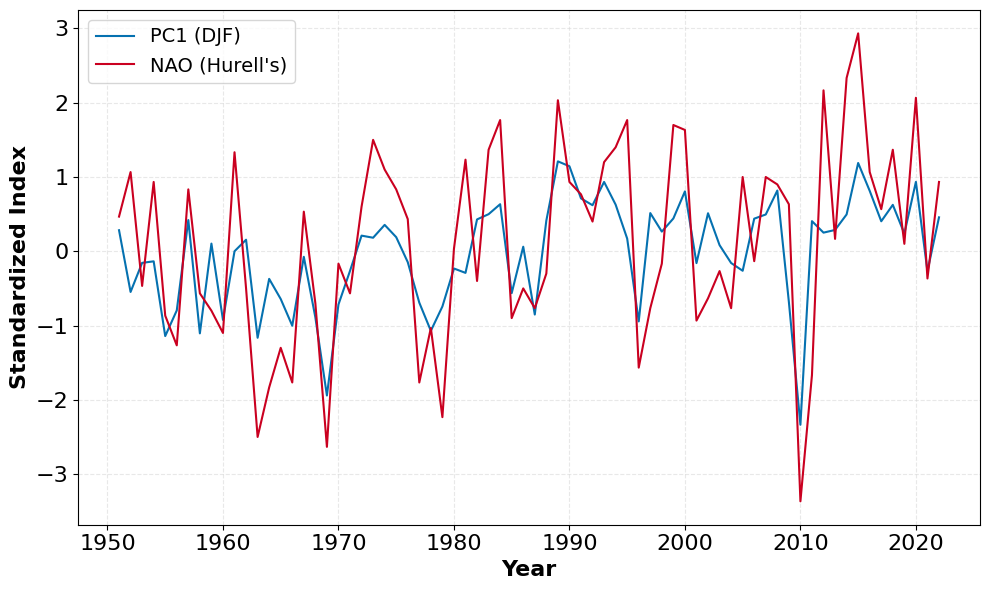

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
gridline_color = "#d3d3d3"

plt.plot(final_df['Year'], final_df['PC1_DJF'], label='PC1 (DJF)', color='#0571b0', linewidth=1.5)
plt.plot(final_df['Year'], final_df['NAO_Hurell'], label="NAO (Hurell's)", color='#ca0020', linewidth=1.5)
#plt.title("Comparison of NAO and EOF-derived PC1 (DJF)", fontsize=16)

plt.ylabel("Standardized Index", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=16, fontweight='bold')
plt.yticks(fontsize=16)
plt.xticks(fontsize=16) 

plt.grid(True, linestyle='--', alpha=0.5, color=gridline_color)

plt.legend(fontsize=14)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\pc1_nao_comparison.png", dpi=800, bbox_inches='tight')
plt.show()

In [15]:
from scipy.stats import pearsonr, spearmanr

r_p, p_p= pearsonr(final_df['PC1_DJF'], final_df['NAO_Hurell'])
r_s, p_s= spearmanr(final_df['PC1_DJF'], final_df['NAO_Hurell'])

print(f"Pearson: r = {r_p:.2f}, p = {p_p:.2f}")
print(f"Spearman: r = {r_s:.2f}, p = {p_s:.2f}")

Pearson: r = 0.76, p = 0.00
Spearman: r = 0.68, p = 0.00


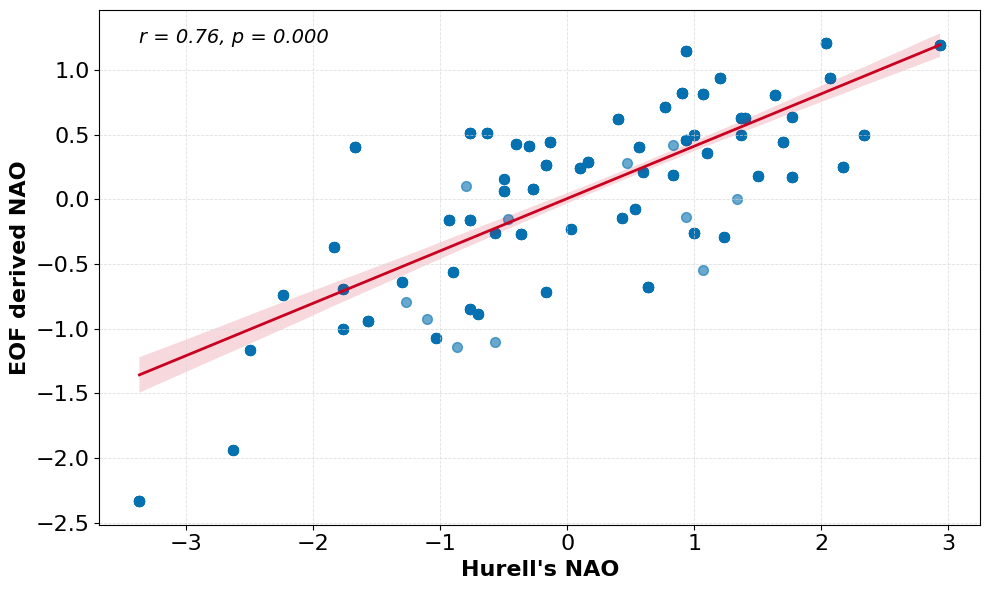

In [ ]:
# Plotting correlation NAO Hurell and PC1

import matplotlib.pyplot as plt
import seaborn as sns

#these 3 lines for heatmap
Correlation_NAO_PC1= ['PC1_DJF', 'NAO_Hurell']
cor1= final_df[Correlation_NAO_PC1]
cor1_matrix= cor1.corr(method='pearson')

gridline_color = "#d3d3d3"

# for plotting regression line 
plt.figure(figsize=(10,6))
sns.regplot(data= final_df,
            x= 'NAO_Hurell',
            y= 'PC1_DJF',
            scatter_kws={'color': '#0571b0', 'alpha': 0.6, 's': 50},
            line_kws= {'color': '#ca0020', 'linewidth': 2},
            ci= 95)

#plt.title("Correlation: PC1 vs Hurrell NAO", fontsize=14, weight='bold')
plt.ylabel("EOF derived NAO", fontsize=16, weight='bold')
plt.xlabel("Hurell's NAO", fontsize=16, weight='bold')
plt.xticks(size=16)
plt.yticks(size=16)

plt.grid(True, linestyle='--', linewidth= 0.6, color=gridline_color, alpha=0.7)

plt.text(x= final_df['NAO_Hurell'].min(),
         y= final_df['PC1_DJF'].max(),
         s= f"r = {r_p:.2f}, p = {p_p:.3f}",
         fontsize=14, fontstyle='italic', color='black')
plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\correlation_plot_nao_pc1.png', dpi=800, bbox_inches='tight')
plt.show()

In [ ]:
final_df['Period']= np.where(final_df['Year'] < 2000, 'Before_2000', 'After_2000')
print(final_df.head())

# Replacing the old unweighted PC1 values by new weighted ones in final_df
before running the correlations again to troubleshoot why NAO~AO had r=1

In [4]:
with open("eof_data_weighted.pkl", "rb") as f:
    eof_data_weighted = pickle.load(f)

    print(eof_data_weighted.keys())
    
print(final_df.head())

dict_keys(['EOF1_DJF', 'EOF2_DJF', 'PC1_DJF', 'PC2_DJF', 'PC1_std_DJF', 'PC2_std_DJF', 'EOF1_MJJAS', 'EOF2_MJJAS', 'PC1_MJJAS', 'PC2_MJJAS', 'PC1_std_MJJAS', 'PC2_std_MJJAS'])
   Year  Temp_DJF  Precip_DJF  Temp_MMJAS  Precip_MMJAS  GlacierId    Glacier  \
0  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
1  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
2  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
3  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   
4  1955 -4.074505    7.468448    9.956315      9.585814       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw   PC1_DJF  \
0 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554  0.294441   
1 -1.13  1.44  0.31  South          -0.32      -1.768       1.340 -0.640205   
2 -2.25  1.40 -0.85  South          -1.17      -1.818       1.350  0.054216   
3 -1.98  1.21 -0.77  

In [5]:
# creating one value per DJF season per year:
PC1_DJF= eof_data_weighted['PC1_DJF']
PC1_std_DJF= eof_data_weighted['PC1_std_DJF']
print(PC1_std_DJF[:10])


# merging PC1 DJF with my dataframe

PC1_std_DJF= PC1_std_DJF[:len(PC1_std_DJF) // 3*3]

pc1_matrix= np.reshape(PC1_std_DJF, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
pc1_seasonal= np.mean(pc1_matrix, axis=1)
years_djf= np.arange(1950, 1950+ len(pc1_seasonal))

pc1_djf_df= pd.DataFrame({
    'Year': years_djf,
    'PC1_DJF': pc1_seasonal
})
print(pc1_djf_df.head())
# dropping the old PC1_DJF column if it exists
final_df = final_df.drop(columns='PC1_DJF', errors='ignore')

# Merge the new seasonal PC1 values into final_df by matching on 'Year'
final_df = pd.merge(final_df, pc1_djf_df, on='Year', how='left')

##-------------------------------------------------------------------------------------------------------------------------##

# merging PC1 MJJAS with my dataframe
# merging PC1 MJJAS with my dataframe

PC1_std_MJJAS= eof_data_weighted['PC1_std_MJJAS']
PC1_std_MJJAS= PC1_std_MJJAS[:len(PC1_std_DJF) // 3*3]

pc1_mjjas_matrix= np.reshape(PC1_std_MJJAS, (-1, 3)) # reshaping where each row is one season; -1 is asking to decide how many ever rows needed to reshape it into 3 columns for each month
pc1_seasonal_mjjas= np.mean(pc1_mjjas_matrix, axis=1)
years_mjjas= np.arange(1950, 1950+ len(pc1_seasonal_mjjas))

pc1_mjjas_df= pd.DataFrame({
    'Year': years_mjjas,
    'PC1_MJJAS': pc1_seasonal_mjjas
})

print(pc1_mjjas_df.head())
# dropping the old PC1_DJF column if it exists
final_df = final_df.drop(columns='PC1_MJJAS', errors='ignore')

# Merge the new seasonal PC1 values into final_df by matching on 'Year'
final_df = pd.merge(final_df, pc1_mjjas_df, on='Year', how='left')


print(final_df.head())



[-0.55343116 -0.59004469  1.15257876 -0.04333896  0.22465571 -1.03109346
 -0.64421305  1.49384207  0.79362419  0.34723793]
   Year   PC1_DJF
0  1950  0.003034
1  1951 -0.283259
2  1952  0.547751
3  1953  0.155957
4  1954  0.135450
   Year  PC1_MJJAS
0  1950   0.438555
1  1951  -0.373563
2  1952   0.265765
3  1953  -0.717093
4  1954   0.272802
   Year  Temp_DJF  Precip_DJF  Temp_MMJAS  Precip_MMJAS  GlacierId    Glacier  \
0  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
1  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
2  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
3  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   
4  1955 -4.074505    7.468448    9.956315      9.585814       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw    PC1_AO  \
0 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554  0.019543   
1 -1.13  1

In [6]:
final_df.to_pickle('final_df2.pkl')

In [7]:
final_df= pd.read_pickle('final_df2.pkl')
print(final_df.head())

   Year  Temp_DJF  Precip_DJF  Temp_MMJAS  Precip_MMJAS  GlacierId    Glacier  \
0  1951 -4.362798    6.185266    9.747061     10.721021       2636  Storbreen   
1  1952 -2.419369    8.807426    9.220020     12.433246       2636  Storbreen   
2  1953 -5.094279    7.743274   10.786901     11.524487       2636  Storbreen   
3  1954 -3.825318    5.963656   10.494399     12.956203       2636  Storbreen   
4  1955 -4.074505    7.468448    9.956315      9.585814       2636  Storbreen   

     Bs    Bw    Ba Region  Cumulative_Ba  Rolling_Bs  Rolling_Bw    PC1_AO  \
0 -1.67  1.13 -0.54  South          -0.63      -1.788       1.554  0.019543   
1 -1.13  1.44  0.31  South          -0.32      -1.768       1.340 -0.042492   
2 -2.25  1.40 -0.85  South          -1.17      -1.818       1.350  0.003598   
3 -1.98  1.21 -0.77  South          -1.94      -1.780       1.386  0.001055   
4 -2.06  1.57 -0.49  South          -2.43      -1.828       1.382 -0.076169   

   NAO_Hurell       Period   PC1_DJF  

In [8]:
r, p = pearsonr(final_df['PC1_AO'], final_df['PC1_DJF'])
print(f"AO vs NAO_DJF correlation: r = {r:.3f}, p = {p:.3f}")

AO vs NAO_DJF correlation: r = -0.986, p = 0.000
